In [2]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
from ClassA import RFI_MakeEnvelopeDataClassA
from Estimadores import *
from matplotlib.gridspec import GridSpec

mpl.rc('font',family = 'Times New Roman')

In [208]:
#-------------------------------------------
#----------------- Parámetros --------------
#r = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
#A = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
r = np.logspace(-4,0,20)
A = np.logspace(-4,0,20)
Sigma_G_sq = 0.001
#-------------------------------------------
#-------------------------------------------
#veces = 1
N = 100000
#-----------------------------------
#-----------------------------------
n = np.size(r)
m = np.size(A)
print (r)

[1.00000000e-04 1.62377674e-04 2.63665090e-04 4.28133240e-04
 6.95192796e-04 1.12883789e-03 1.83298071e-03 2.97635144e-03
 4.83293024e-03 7.84759970e-03 1.27427499e-02 2.06913808e-02
 3.35981829e-02 5.45559478e-02 8.85866790e-02 1.43844989e-01
 2.33572147e-01 3.79269019e-01 6.15848211e-01 1.00000000e+00]


In [18]:
# Inicializacion del vector A_ini
vec_A_ini       = np.zeros((m,n))
vec_r_ini       = np.zeros((m,n))
vec_Sigmag2_ini = np.zeros((m,n))

for j in range(len(r)):
    print (j)
    for i in range(len(A)):
        print (i)
        env_data_Norm,env_data_DesNorm = RFI_MakeEnvelopeDataClassA(A[i],r[j],10,N,Sigma_G_sq)

        # Estimador inicial
        A_ini,Sigmag2_ini,r_ini = est_inicial(env_data_DesNorm)
        vec_A_ini[i,j]          = A_ini
        vec_Sigmag2_ini[i,j]    = Sigmag2_ini
        vec_r_ini[i,j]          = r_ini

print ('FIN')

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
3
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
4
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
5
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
6
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
7
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
8
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
9
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
10
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
11
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
12
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
13
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
14
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
15
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
16
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
17
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
18
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
19


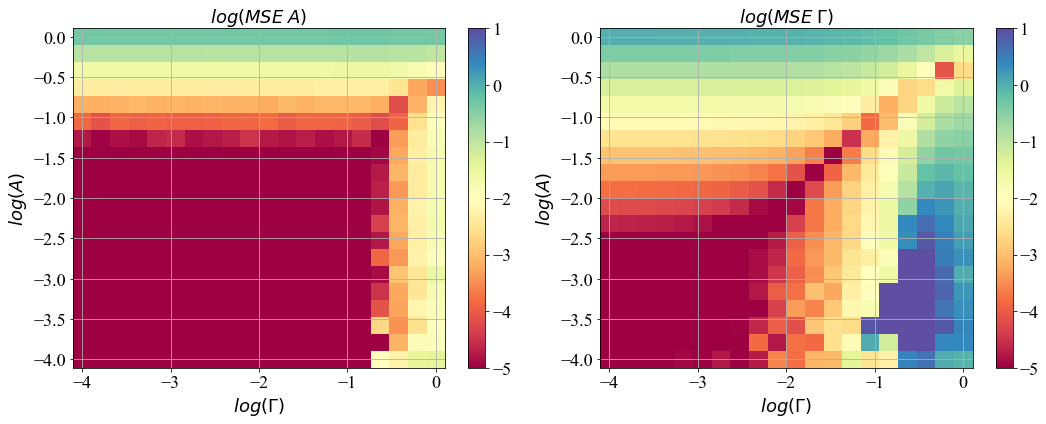

In [210]:
## ------------------ Matriz MSE --------------------------
matriz_A = np.zeros((m,n))
matriz_r = np.zeros((m,n))
matriz_MSE_A = np.zeros((m,n))
matriz_MSE_r = np.zeros((m,n))

for j in range(len(r)):
    for i in range(len(A)):
        matriz_A[i,j] = A[i]
        matriz_r[i,j] = r[i]

for j in range(len(r)):
    for i in range(len(A)):
        matriz_MSE_A[i,j] = (vec_A_ini[i,j] - matriz_A[i,j])**2
        matriz_MSE_r[i,j] = (vec_r_ini[i,j] - matriz_r[i,j])**2
        if matriz_MSE_A[i,j] < 0.000001:
            matriz_MSE_A[i,j] = 0.0000001

# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(15, 6))
gs0 = GridSpec(nrows=1, ncols=2)

ax0 = fig1.add_subplot(gs0[0, 0])
#ax0.title.set_text(r'$log(MSE\;A)$')
ax0.set_title(r'$log(MSE\;A)$', fontsize = 18)
ax0.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax0.set_ylabel('$log(A)$',fontsize = 18)
h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A), vmin = -5, vmax = 1,cmap='Spectral')
cbar0 = fig1.colorbar(h0)
ax0.grid(True)
cbar0.ax.tick_params(labelsize=18)
ax0.tick_params(axis="x", labelsize=18)
ax0.tick_params(axis="y", labelsize=18)

ax1 = fig1.add_subplot(gs0[0, 1])
#ax1.title.set_text(r'$log(MSE\;\Gamma)$')
ax1.set_title(r'$log(MSE\;\Gamma)$', fontsize = 18)
ax1.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax1.set_ylabel('$log(A)$',fontsize = 18)
h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r), vmin = -5, vmax = 1,cmap='Spectral')
cbar = fig1.colorbar(h1)
ax1.grid(True)
cbar.ax.tick_params(labelsize=18)
ax1.tick_params(axis="x", labelsize=18)
ax1.tick_params(axis="y", labelsize=18)

plt.tight_layout()

fig1.savefig('ErrorEstimacionMapaColor.pdf', bbox_inches = 'tight',pad_inches = 0.1)

In [7]:
#-------------------------------------------
#----------------- Parámetros --------------
#r = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
#A = np.array([0.0001, 0.001, 0.01, 0.1, 1, 2])
r = np.logspace(-4,0,20)
A = np.logspace(-4,0,20)
Sigma_G_sq = 0.001
#-------------------------------------------
#-------------------------------------------
veces = 2
N = 1000
#-----------------------------------
#-----------------------------------
n = np.size(r)
m = np.size(A)
print (r)

[1.00000000e-04 1.62377674e-04 2.63665090e-04 4.28133240e-04
 6.95192796e-04 1.12883789e-03 1.83298071e-03 2.97635144e-03
 4.83293024e-03 7.84759970e-03 1.27427499e-02 2.06913808e-02
 3.35981829e-02 5.45559478e-02 8.85866790e-02 1.43844989e-01
 2.33572147e-01 3.79269019e-01 6.15848211e-01 1.00000000e+00]


In [8]:
# Inicializacion de vectores de estimaciones estimador Kanemoto
A_est_Kane      = np.zeros((veces,m,n))
K_est_Kane      = np.zeros((veces,m,n))
r_est_Kane      = np.zeros((veces,m,n))

# Inicializacion de vectores de estimaciones estimador Zabin
A_est_Zabin = np.zeros((veces,m,n))
K_est_Zabin = np.zeros((veces,m,n))
time_Zabin  = np.zeros((veces,m,n))

for k in range(veces):
    print ('veces =', veces)
    for j in range(len(r)):
        print (j)
        for i in range(len(A)):
        
            # Estimador Zabin
            env_data_Norm,env_data_DesNorm = RFI_MakeEnvelopeDataClassA(A[i],r[j],10,N,Sigma_G_sq)
            A_est_Zabin[k,i,j],K_est_Zabin[k,i,j] = Est_Momentos_Zabin_Poor(env_data_Norm)
        
            # Estimador Kanemoto
            A_est_Kane[k,i,j],r_est_Kane[k,i,j],K_est_Kane[k,i,j] = Est_Momentos_Kanemoto(env_data_Norm)

print ('FIN')

veces = 2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
veces = 2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
FIN


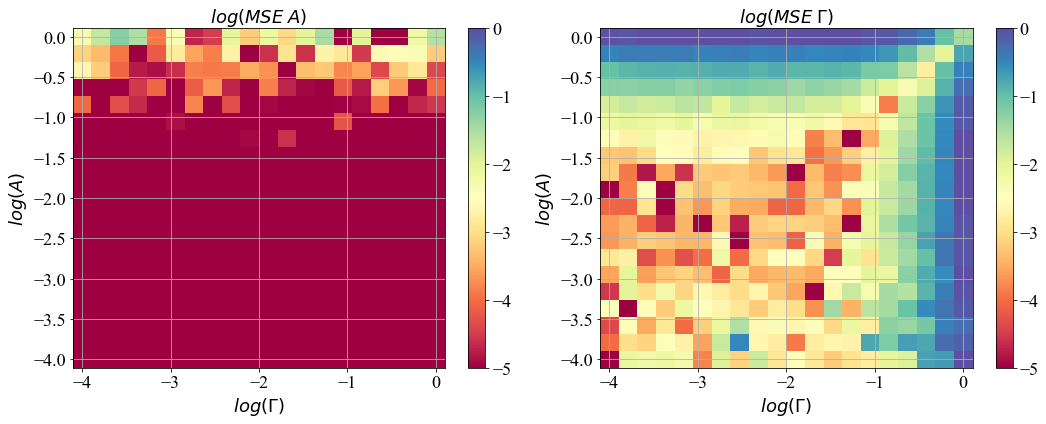

In [226]:
## ------------------ Matriz MSE Kanemoto--------------------------
matriz_A_Kane = np.zeros((veces,m,n))
matriz_r_Kane = np.zeros((veces,m,n))
matriz_MSE_A_Kane = np.zeros((m,n))
matriz_MSE_r_Kane = np.zeros((m,n))

for k in range (veces):
    for j in range(len(r)):
        for i in range(len(A)):
            matriz_A_Kane[i,j] = A[i]
            matriz_r_Kane[i,j] = r[i]

for k in range(veces):
    for j in range(len(r)):
        for i in range(len(A)):
            matriz_MSE_A_Kane[i,j] = (A_est_Kane[i,j] - matriz_A_Kane[i,j])**2
            matriz_MSE_r_Kane[i,j] = (r_est_Kane[i,j] - matriz_r_Kane[i,j])**2
            if matriz_MSE_A_Kane[i,j] < 0.000001:
                matriz_MSE_A_Kane[i,j] = 0.0000001
            if matriz_MSE_r_Kane[i,j] < 0.000001:
                matriz_MSE_r_Kane[i,j] = 0.0000001

# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(15, 6))
gs0 = GridSpec(nrows=1, ncols=2)

ax0 = fig1.add_subplot(gs0[0, 0])
#ax0.title.set_text(r'$log(MSE\;A)$')
ax0.set_title(r'$log(MSE\;A)$', fontsize = 18)
ax0.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax0.set_ylabel('$log(A)$',fontsize = 18)
h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A_Kane), vmin = -5, vmax = 0,cmap='Spectral')
cbar0 = fig1.colorbar(h0)
ax0.grid(True)
cbar0.ax.tick_params(labelsize=18)
ax0.tick_params(axis="x", labelsize=18)
ax0.tick_params(axis="y", labelsize=18)

ax1 = fig1.add_subplot(gs0[0, 1])
#ax1.title.set_text(r'$log(MSE\;\Gamma)$')
ax1.set_title(r'$log(MSE\;\Gamma)$', fontsize = 18)
ax1.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax1.set_ylabel('$log(A)$',fontsize = 18)
h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r_Kane), vmin = -5, vmax = 0,cmap='Spectral')
cbar = fig1.colorbar(h1)
ax1.grid(True)
cbar.ax.tick_params(labelsize=18)
ax1.tick_params(axis="x", labelsize=18)
ax1.tick_params(axis="y", labelsize=18)

plt.tight_layout()

fig1.savefig('ErrorEstimacionMapaColorKanemoto.pdf', bbox_inches = 'tight',pad_inches = 0.1)

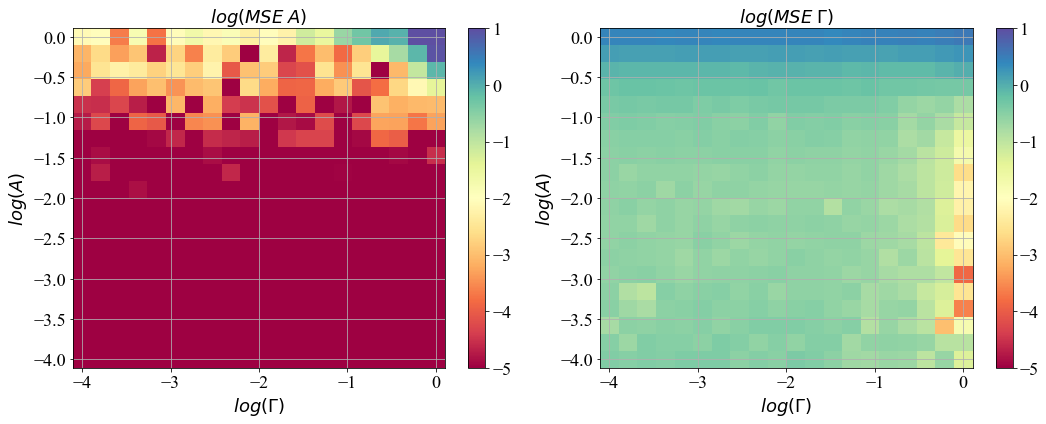

In [216]:
## ------------------ Matriz MSE Zabin-Poor--------------------------
matriz_A_Zabin = np.zeros((m,n))
matriz_r_Zabin = np.zeros((m,n))
matriz_MSE_A_Zabin = np.zeros((m,n))
matriz_MSE_r_Zabin = np.zeros((m,n))

for j in range(len(r)):
    for i in range(len(A)):
        matriz_A_Zabin[i,j] = A[i]
        matriz_r_Zabin[i,j] = r[i]

for j in range(len(r)):
    for i in range(len(A)):
        matriz_MSE_A_Zabin[i,j] = (A_est_Zabin[i,j] - matriz_A_Zabin[i,j])**2
        matriz_MSE_r_Zabin[i,j] = (K_est_Zabin[i,j]/A_est_Zabin[i,j] - matriz_r_Zabin[i,j])**2
        if matriz_MSE_A_Zabin[i,j] < 0.000001:
            matriz_MSE_A_Zabin[i,j] = 0.0000001
        if matriz_MSE_r_Zabin[i,j] < 0.000001:
            matriz_MSE_r_Zabin[i,j] = 0.0000001

# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(15, 6))
gs0 = GridSpec(nrows=1, ncols=2)

ax0 = fig1.add_subplot(gs0[0, 0])
#ax0.title.set_text(r'$log(MSE\;A)$')
ax0.set_title(r'$log(MSE\;A)$', fontsize = 18)
ax0.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax0.set_ylabel('$log(A)$',fontsize = 18)
h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A_Zabin), vmin = -5, vmax = 1,cmap='Spectral')
cbar0 = fig1.colorbar(h0)
ax0.grid(True)
cbar0.ax.tick_params(labelsize=18)
ax0.tick_params(axis="x", labelsize=18)
ax0.tick_params(axis="y", labelsize=18)

ax1 = fig1.add_subplot(gs0[0, 1])
#ax1.title.set_text(r'$log(MSE\;\Gamma)$')
ax1.set_title(r'$log(MSE\;\Gamma)$', fontsize = 18)
ax1.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax1.set_ylabel('$log(A)$',fontsize = 18)
h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r_Zabin), vmin = -5, vmax = 1,cmap='Spectral')
cbar = fig1.colorbar(h1)
ax1.grid(True)
cbar.ax.tick_params(labelsize=18)
ax1.tick_params(axis="x", labelsize=18)
ax1.tick_params(axis="y", labelsize=18)

plt.tight_layout()

fig1.savefig('ErrorEstimacionMapaColorZabinPoor.pdf', bbox_inches = 'tight',pad_inches = 0.1)

In [217]:
# Inicializacion de vectores de estimaciones estimador EM
A_est_EM = np.zeros((m,n))
K_est_EM = np.zeros((m,n))
N = 1000

for j in range(len(r)):
    print (j)
    for i in range(len(A)):
        env_data_Norm,env_data_DesNorm = RFI_MakeEnvelopeDataClassA(A[i],r[j],10,N,Sigma_G_sq)
        
        # Estimador inicial
        A_ini,Sigmag2_ini,r_ini = est_inicial(env_data_DesNorm)
        vec_A_ini[i,j]          = A_ini
        vec_Sigmag2_ini[i,j]    = Sigmag2_ini
        vec_r_ini[i,j]          = r_ini
        
        # Estimador EM
        A_est_EM[i,j],NumIter = RFI_EMParamA(N, 10, env_data_Norm,A_ini,A_ini*r_ini,9)
        A_errado,K_est_EM[i,j],NumIter = RFI_EMTwoParamEst(N, 10, env_data_Norm, A_ini, A_ini*r_ini)

print ('FIN')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
FIN


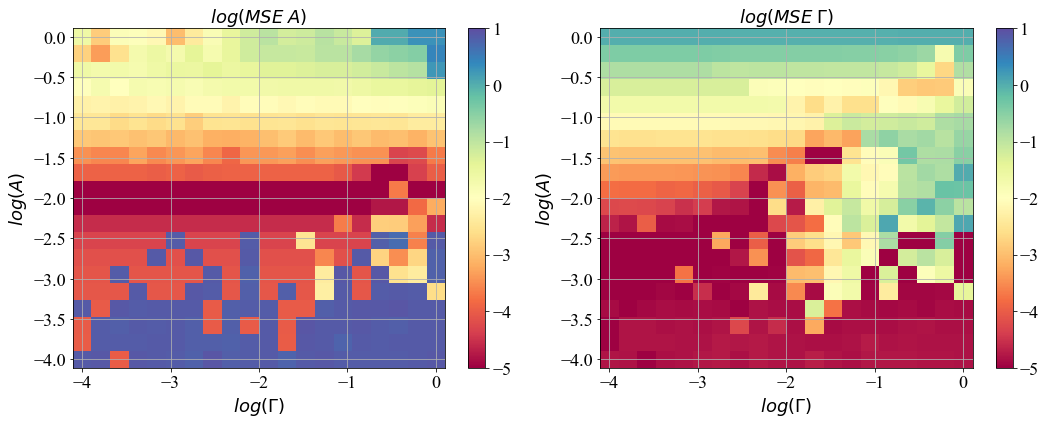

In [218]:
## ------------------ Matriz MSE EM--------------------------
matriz_A_EM = np.zeros((m,n))
matriz_r_EM = np.zeros((m,n))
matriz_MSE_A_EM = np.zeros((m,n))
matriz_MSE_r_EM = np.zeros((m,n))

for j in range(len(r)):
    for i in range(len(A)):
        matriz_A_EM[i,j] = A[i]
        matriz_r_EM[i,j] = r[i]

for j in range(len(r)):
    for i in range(len(A)):
        matriz_MSE_A_EM[i,j] = (A_est_EM[i,j] - matriz_A_EM[i,j])**2
        matriz_MSE_r_EM[i,j] = (K_est_EM[i,j]/A_est_EM[i,j] - matriz_r_EM[i,j])**2
        if matriz_MSE_A_EM[i,j] < 0.000001:
            matriz_MSE_A_EM[i,j] = 0.0000001
        if matriz_MSE_r_EM[i,j] < 0.000001:
            matriz_MSE_r_EM[i,j] = 0.0000001

# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(15, 6))
gs0 = GridSpec(nrows=1, ncols=2)

ax0 = fig1.add_subplot(gs0[0, 0])
#ax0.title.set_text(r'$log(MSE\;A)$')
ax0.set_title(r'$log(MSE\;A)$', fontsize = 18)
ax0.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax0.set_ylabel('$log(A)$',fontsize = 18)
h0 = ax0.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_A_EM), vmin = -5, vmax = 1,cmap='Spectral')
cbar0 = fig1.colorbar(h0)
ax0.grid(True)
cbar0.ax.tick_params(labelsize=18)
ax0.tick_params(axis="x", labelsize=18)
ax0.tick_params(axis="y", labelsize=18)

ax1 = fig1.add_subplot(gs0[0, 1])
#ax1.title.set_text(r'$log(MSE\;\Gamma)$')
ax1.set_title(r'$log(MSE\;\Gamma)$', fontsize = 18)
ax1.set_xlabel('$log(\Gamma)$',fontsize = 18)
ax1.set_ylabel('$log(A)$',fontsize = 18)
h1 = ax1.pcolormesh(np.log10(r),np.log10(A),np.log10(matriz_MSE_r_EM), vmin = -5, vmax = 1,cmap='Spectral')
cbar = fig1.colorbar(h1)
ax1.grid(True)
cbar.ax.tick_params(labelsize=18)
ax1.tick_params(axis="x", labelsize=18)
ax1.tick_params(axis="y", labelsize=18)

plt.tight_layout()

fig1.savefig('ErrorEstimacionMapaColorEM.pdf', bbox_inches = 'tight',pad_inches = 0.1)

In [114]:
# ----------- Cálculo del error cuadrático medio en la est. de A -------------------
mse_est_simple  = np.sum((vec_A_ini - A)**2,axis=0)/veces
A_prom = np.sum(vec_A_ini,axis=0)/veces

# ----------- Cálculo del error cuadrático medio en la est. de r -------------------
mse_est_simple_r = np.sum((vec_r_ini - r)**2,axis=0)/veces
r_prom = np.sum(vec_r_ini,axis=0)/veces

# ----------- Cálculo del error cuadrático medio en la est. de r -------------------
mse_est_simple_sigma = np.sum((vec_Sigmag2_ini - Sigma_G_sq)**2,axis=0)/veces
Sigma_G_sq_prom = np.sum(vec_Sigmag2_ini,axis=0)/veces

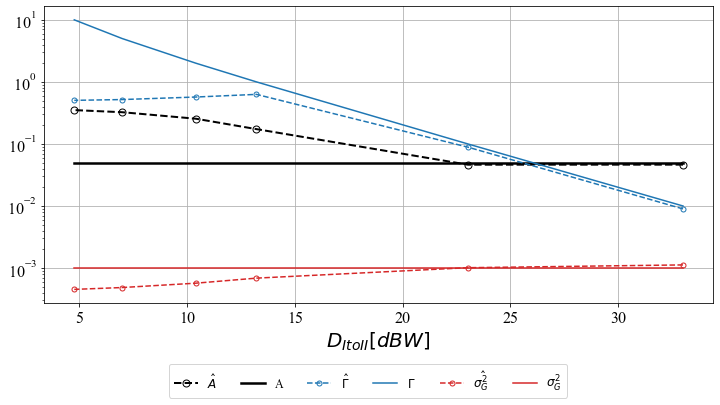

In [115]:
vector_A = np.array([A,A,A,A,A,A])
vector_Sigma_G_sq = np.array([Sigma_G_sq,Sigma_G_sq,Sigma_G_sq,Sigma_G_sq,Sigma_G_sq,Sigma_G_sq])
# -------------- FIGURAS -------------------------------------------------------------
# ------------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(12, 12))
gs0 = GridSpec(nrows=2, ncols=2)

ax0 = fig1.add_subplot(gs0[0, :])
#ax0.set_xscale('log')
ax0.set_yscale('log')
#ax0.title.set_text(r'MSE')
#ax0.set_ylabel(r'MSE A',fontsize = 14)
ax0.set_xlabel(r'$D_{ItoII}[dBW]$',fontsize = 20)
ax0.plot(D1a2,A_prom, '--o', fillstyle = 'none', markersize = 7, color = 'black', linewidth = 2, label = '$\hat{A}$')
ax0.plot(D1a2, vector_A, c = 'black', linewidth = 2.5, label = 'A')
ax0.plot(D1a2,r_prom, '--o', fillstyle = 'none', markersize = 5, color = 'tab:blue', label = '$\hat{\Gamma}$')
ax0.plot(D1a2,r,c="tab:blue", label = '$\Gamma$')
ax0.plot(D1a2,Sigma_G_sq_prom, '--o', fillstyle = 'none', markersize = 5, color = 'tab:red', label = '$\hat{\sigma_{G}^{2}}$')
ax0.plot(D1a2,vector_Sigma_G_sq,c="tab:red", label = '$\sigma_{G}^{2}$')
ax0.grid(True)
ax0.tick_params(axis="x", labelsize=16)
ax0.tick_params(axis="y", labelsize=16)

labels = ['$\hat{A}$', 'A', '$\hat{\Gamma}$', '$\Gamma$', '$\hat{\sigma_{G}^{2}}$', '$\sigma_{G}^{2}$']
fig1.legend(labels=labels,bbox_to_anchor=(0.5, 0.42),loc="lower center", ncol=6, fontsize = 12)

#plt.tight_layout()
plt.show()

fig1.savefig('Figure_4_en.pdf', bbox_inches = 'tight',pad_inches = 0.1)